# Out file Quick Check

In [1]:
filename = 'DBZ_VR.out'

with open(filename, 'r') as file:
    for line_number, line in enumerate(file, start=1):
        if 'Error' in line:
            print(f"Line {line_number}: {line.strip()}")


Line 4481: OSError: [Errno 18] Invalid cross-device link: 'Prior.nc' -> '/scratch/home/jessica.mcdonald/LETKF_runs/DBZ_VR/Prior_2024-05-08_20:00:00.nc'
Line 4947: OSError: [Errno 18] Invalid cross-device link: 'Prior.nc' -> '/scratch/home/jessica.mcdonald/LETKF_runs/DBZ_VR/Prior_2024-05-08_20:05:00.nc'
Line 5413: OSError: [Errno 18] Invalid cross-device link: 'Prior.nc' -> '/scratch/home/jessica.mcdonald/LETKF_runs/DBZ_VR/Prior_2024-05-08_20:10:00.nc'
Line 5879: OSError: [Errno 18] Invalid cross-device link: 'Prior.nc' -> '/scratch/home/jessica.mcdonald/LETKF_runs/DBZ_VR/Prior_2024-05-08_20:15:00.nc'
Line 6345: OSError: [Errno 18] Invalid cross-device link: 'Prior.nc' -> '/scratch/home/jessica.mcdonald/LETKF_runs/DBZ_VR/Prior_2024-05-08_20:20:00.nc'
Line 6811: OSError: [Errno 18] Invalid cross-device link: 'Prior.nc' -> '/scratch/home/jessica.mcdonald/LETKF_runs/DBZ_VR/Prior_2024-05-08_20:25:00.nc'


# CM1 outfile Quick Check

In [2]:
#cm1.out files are deleted if you're redoing a DA experiment without rerunning the "spin up" time, so these won't contain old errors
experiment = 'AllExperiments/DBZ_VR'

import glob 
files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/{experiment}/member*/cm1.out'))
for f in files:
    print(f.split('/')[-2])
    with open(f, 'r') as file:
        for line_number, line in enumerate(file, start=1):
            if 'error' in line:
                print(f"Line {line_number}: {line.strip()}")
            if 'denied' in line:
                print(f"Line {line_number}: {line.strip()}")

member001
Line 68629: netcdf status returned an error:           13  ... stopping program
Line 68631: Permission denied
member002
member003
member004
member005
member006
member007
member008
member009
member010
member011
member012
member013
member014
member015
member016
member017
member018
member019
member020
member021
member022
member023
member024
member025
member026
member027
member028
member029
member030
member031
member032
member033
Line 28395: netcdf status returned an error:            2  ... stopping program
Line 31343: netcdf status returned an error:            2  ... stopping program
Line 34291: netcdf status returned an error:            2  ... stopping program
Line 37239: netcdf status returned an error:            2  ... stopping program
Line 40187: netcdf status returned an error:            2  ... stopping program
Line 43135: netcdf status returned an error:            2  ... stopping program
Line 46083: netcdf status returned an error:            2  ... stopping program


# Monitor ongoing experimets
## 1. Plot Prior and Posterior compared to obs
## 2. Check stats files
## 3. Overview of a single member 

In [5]:
import sys
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import json
import ctables


from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime
from fsrc.fpython2 import fstate, addbubbles_box, obs_2_grid3d

import contextlib
import io

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

def get_dbz(analysis_time, experiment):
    myDTstring = analysis_time.strftime('%Y,%m,%d,%H,%M,%S')
    with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/{experiment}/{experiment}.exp', 'rb') as f:
        exper = json.load(f)
    files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,);
    
    mystate = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
    ens.ens_CM1_C2A(mystate)
    ens.ens_CM1_coords(mystate)
    
    obs = ens.ens_GRID_RELECTIVITY(mystate)
    return obs

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl    
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})


 FORTRAN OBS_2_GRID3D:  dims           128         128          51         276
 FORTRAN OBS_2_GRID3D:  dx, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  dy, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  vscale     2000.00000    
 FORTRAN OBS_2_GRID3D:    obs   0.189707905       52.9794121    
 FORTRAN OBS_2_GRID3D:  x-obs   -25186.2715       41160.8633    
 FORTRAN OBS_2_GRID3D:  y-obs   -49038.6367      -12966.6533    
 FORTRAN OBS_2_GRID3D:  z-obs    1000.00000       8000.00000    
 FORTRAN OBS_2_GRID3D:  x-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  y-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  z-grid   75.0000000       19700.0000    


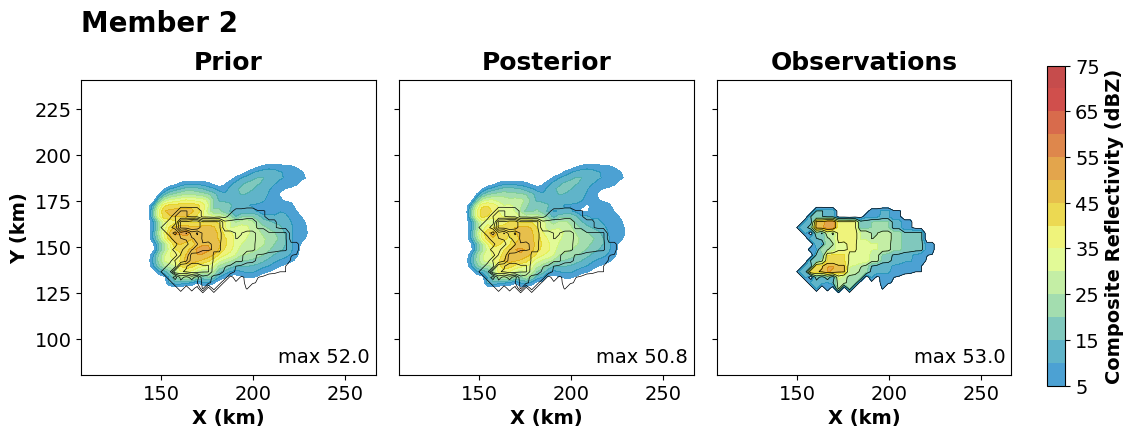

 FORTRAN OBS_2_GRID3D:  dims           128         128          51         254
 FORTRAN OBS_2_GRID3D:  dx, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  dy, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  vscale     2000.00000    
 FORTRAN OBS_2_GRID3D:    obs    5.29287755E-02   48.5675812    
 FORTRAN OBS_2_GRID3D:  x-obs   -19154.3262       47143.1367    
 FORTRAN OBS_2_GRID3D:  y-obs   -49036.9570      -6980.61719    
 FORTRAN OBS_2_GRID3D:  z-obs    1000.00000       8000.00000    
 FORTRAN OBS_2_GRID3D:  x-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  y-grid  -178500.000       202500.000    
 FORTRAN OBS_2_GRID3D:  z-grid   75.0000000       19700.0000    


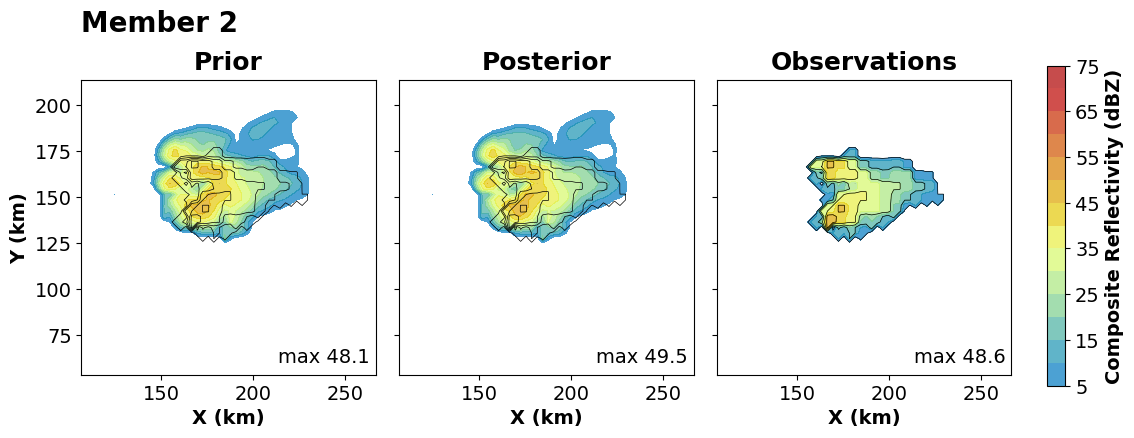

In [6]:
#MEMBER = 0

experiment = 'DBZ_only'
TIME = 9

for TIME in [17,18]:#np.arange(10,21,2):

    for MEMBER in [2]:
    
        fig, axes= plt.subplots(1,3, figsize=(12, 4), sharex=True, sharey=True)
        
        
        # read in data
        if MEMBER == 0:
            fig.suptitle(f'Ensemble Mean',x=.19, fontsize=20, weight='bold', y=1.04)
            cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/{experiment}/member{MEMBER:03d}/cm1_post_{TIME:06d}.nc',decode_timedelta=True)
        else:
            fig.suptitle(f'Member {MEMBER}',x=.19, fontsize=20, weight='bold', y=1.04)
            cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/{experiment}/member{MEMBER:03d}/cm1rst_{TIME:06d}.nc',decode_timedelta=True)
        prior = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/{experiment}/member{MEMBER:03d}/cm1_prior_{TIME:06d}.nc',decode_timedelta=True)
        
        analysis_time = DT.datetime(cm1.year, cm1.month, cm1.day, cm1.hour, cm1.minute)+DT.timedelta(seconds=int(cm1.time.values[0]/1e9))
        with contextlib.redirect_stdout(io.StringIO()) as f: # this just silences all the obnoxious output
            dbz_obs = get_dbz(analysis_time, experiment); # this is cref 
        
        for ax, data in zip(axes, [prior.dbz[0].max(axis=0).values, cm1.dbz[0].max(axis=0).values, dbz_obs[0]]):
            im=ax.contourf(cm1.xh/1000, cm1.yh/1000, data, levels=np.arange(5, 80, 5),cmap=ctables.REF_default, alpha=0.7)
            ax.text(0.98, 0.04, f'max {data.max():.1f}',ha='right', fontsize=14,transform=ax.transAxes )
            
        
        axes[0].set_ylabel('Y (km)')
        for ax, title in zip(axes, ['Prior', 'Posterior', 'Observations']):
            ax.set_title(title, y=1.01, weight='bold')
            ax.set_aspect('equal')
            ax.set_xlabel('X (km)')
            ax.contour(cm1.xh/1000, cm1.yh/1000, dbz_obs[:].max(axis=0), levels=np.arange(5, 80, 10),colors='k', linewidths=0.5)
    
            # center plots on max observations
            z,y,x = np.where(dbz_obs ==dbz_obs.max())
            cx = cm1.xh[x[0]]/1000; cy=cm1.yh[y[0]]/1000
            buf=80
            ax.set_xlim(cx-buf+20, cx+buf+20)
            ax.set_ylim(cy-buf, cy+buf)
    
        
        cbar_ax = fig.add_axes([0.93, 0.1, 0.015, 0.8])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Composite Reflectivity (dBZ)', weight='bold')
        plt.subplots_adjust(wspace=0.08, hspace=0.3)
        plt.show()
        
        cm1.close()
        prior.close()

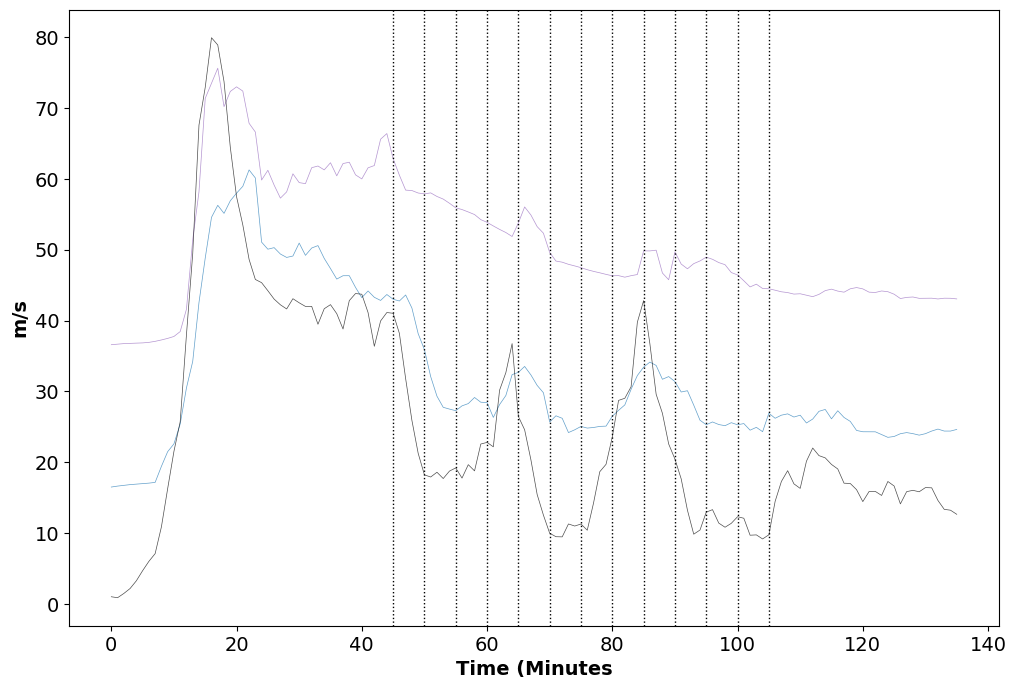

In [19]:
# look at stats files to make sure nothing is "blowing up"
# be very careful with this.... it may be locking the stats file and causing big problems for the experiments (?)
mem=3

fig=plt.figure(figsize=(12,8))

for mem in [1]:#np.arange(1,37,1):
    stats = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/{experiment}/member{mem:03d}/cm1out_stats.nc',decode_timedelta=True)
    plt.plot(stats.time/1e9/60, stats.umax, label='Max U', ls='-',alpha=0.7, color='C4', lw=0.5)
    plt.plot(stats.time/1e9/60, stats.vmax, label='Max V', ls='-',alpha=0.7, color='C0', lw=.5)
    plt.plot(stats.time/1e9/60, stats.wmax, label='Max w', ls='-',alpha=0.7, color='k', lw=.5)
    for h in np.arange(45, 110, 5):
        plt.axvline(h, color='k', ls=':', lw=1)
    plt.xlabel('Time (Minutes')
    plt.ylabel('m/s')
    #plt.legend()
    stats.close()

In [6]:
#MEMBER = 0
#TIME = 11

for MEMBER in [4]:

    for TIME in np.arange(5, 28,2):

        fig, ax= plt.subplots(1,1, figsize=(4, 4), sharex=True, sharey=True)
        
        
        # read in data
        if MEMBER == 0:
            fig.suptitle(f'Ensemble Mean', fontsize=20, weight='bold', y=1.01)
            cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{MEMBER:03d}/cm1_post_{TIME:06d}.nc',decode_timedelta=True)
        else:
            fig.suptitle(f'Member {MEMBER}', fontsize=20, weight='bold', y=1.01)
            cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{MEMBER:03d}/cm1rst_{TIME:06d}.nc',decode_timedelta=True)
    
        im=ax.contourf(cm1.xh/1000, cm1.yh/1000, cm1.dbz[0].max(axis=0).values, levels=np.arange(10, 80, 5),cmap=ctables.REF_default, alpha=0.5)

        # try:
        #     analysis_time = DT.datetime(cm1.year, cm1.month, cm1.day, cm1.hour, cm1.minute)+DT.timedelta(seconds=int(cm1.time.values[0]/1e9))
        #     with contextlib.redirect_stdout(io.StringIO()) as f: # this just silences all the obnoxious output
        #         dbz_obs = get_dbz(analysis_time); # this is cref 
        #     ax.contour(cm1.xh/1000, cm1.yh/1000, dbz_obs[:].max(axis=0), levels=np.arange(10, 80, 10),colors='k', linewidths=0.5)
        # except:
        #     pass
        
        ax.text(0.98, 0.04, f'max {cm1.dbz[0].max():.1f}',ha='right', fontsize=14,transform=ax.transAxes )
        ax.set_ylabel('Y (km)')
        ax.set_aspect('equal')
        ax.set_xlabel('X (km)')
 
        cbar_ax = fig.add_axes([0.93, 0.1, 0.035, 0.8])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Composite Reflectivity (dBZ)', weight='bold')
        plt.subplots_adjust(wspace=0.08, hspace=0.3)
        
        cm1.close()
    #prior.close()

array([   0.,   60.,  120.,  180.,  240.,  300.,  360.,  420.,  480.,
        540.,  600.,  660.,  720.,  780.,  840.,  900.,  960., 1020.,
       1080., 1140., 1200., 1260., 1320., 1380., 1440., 1500., 1560.,
       1620., 1680., 1740., 1800., 1860., 1920., 1980., 2040., 2100.,
       2160., 2220., 2280., 2340., 2400., 2460., 2520., 2580., 2640.,
       2700., 2760., 2820., 2880., 2940., 3000., 3060., 3120., 3180.,
       3240., 3300., 3360., 3420., 3480., 3540., 3600., 3660., 3720.,
       3780., 3840., 3900., 3960., 4020., 4080., 4140., 4200., 4260.,
       4320., 4380., 4440., 4500., 4560., 4620., 4680., 4740., 4800.,
       4860., 4920., 4980., 5040., 5100., 5160., 5220., 5280., 5340.,
       5400., 5460., 5520., 5580., 5640., 5700., 5760., 5820., 5880.,
       5940., 6000., 6060., 6120., 6180., 6240., 6300., 6360., 6420.,
       6480., 6540., 6600., 6660., 6720., 6780., 6840., 6900., 6960.,
       7020., 7080., 7140., 7200., 7260., 7320., 7380., 7440., 7500.,
       7560., 7620.,

# Delete files to redo DA experiments without having to re-run spin up

note: this may break your cm1out_stats files(?)

In [3]:
import sys
import os
import numpy as np
import math as M
import datetime as DT 
from netCDF4 import *
import glob
import json
import ens

In [10]:
with open(f'{experiment_location}{experiment}.exp', 'rb') as mf:
    exper = json.load(mf)

In [12]:
files, myDT = ens.FindRestartFiles(exper, rtime.strftime('%Y,%m,%d,%H,%M,%S'), ret_exp=False,)


 ==> FindRestartFiles: Date and time supplied is 2024_05_09 00:00:00


  ERROR!!!

 ==>!! FindRestartFile: A file with the restart time of 17100 cannot be found, exiting!!!


  ERROR!!!


SystemExit: -1

/home/jessica.mcdonald/miniconda3/envs/letkf_env/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [8]:
#### REDOING EXPERIMENTS - THIS ALLOWS YOU TO DELETE FROM A SPECIFIED LOCATION TO HELP WITH CM1 BUGS

ARE_YOU_SURE = False
experiment = 'DBZ_VR'

start_delete = DT.datetime(2024,5,8,20,0) # will delete all existing files after this time
#experiment_location = f'/work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/{experiment}/'
experiment_location = f'/work2/jessica.mcdonald/LETKF_work2/AllExperiments/{experiment}/'

exp_length = 240 # minutes... this doesn't have to be exact
outfile_freq = 5 # minutes... how often does cm1 output? 

with open(f'{experiment_location}{experiment}.exp', 'rb') as mf:
    exper = json.load(mf)


delete_list = []
for i,rtime in enumerate(np.arange(start_delete, start_delete+DT.timedelta(minutes=exp_length+outfile_freq),DT.timedelta(minutes=outfile_freq) )):
    rtime = rtime.astype(DT.datetime)

    if i == 0: # find the cm1 ID for your specified start time, so you can loop over higher numbers
        files, myDT = ens.FindRestartFiles(exper, rtime.strftime('%Y,%m,%d,%H,%M,%S'), ret_exp=False,)
        start_num = int(files[0].split('.')[-2][-2:]) + 1 # you shouldn't delete that time step

    inf = experiment_location+rtime.strftime('Inflation_%Y-%m-%d_%H:%M:%S.nc')
    prior = experiment_location+rtime.strftime('Prior_%Y-%m-%d_%H:%M:%S.nc')
    cm1out = experiment_location+'cm1.out'
    delete_list.extend([inf, prior])

#start_num=24 # you can manually set the number if you'd prefer (and you don't care about inflation or prior files)
        
# for each member, get rid of anything after the start delete time      
for i in range(1, exper['ne']+1):
    main = experiment_location+f'member{i:03d}/'
    delete_list.append(main+f'cm1.out')
    for oi in range(start_num, int(exp_length/outfile_freq),1):
        delete_list.append(main+f'cm1rst_{oi:06d}.nc')
        delete_list.append(main+f'cm1_prior_{oi:06d}.nc')
         
for d in delete_list:
    if os.path.exists(d):
        cmd = f'rm {d}'
        if ARE_YOU_SURE:
            os.system(cmd)
        else:            
            print(cmd)      


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 2700 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ_VR/member001/cm1rst_000009.nc
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/Inflation_2024-05-08_20:00:00.nc
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/Prior_2024-05-08_20:00:00.nc
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/Inflation_2024-05-08_20:05:00.nc
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/Prior_2024-05-08_20:05:00.nc
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/Inflation_2024-05-08_20:10:00.nc
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/Prior_2024-05-08_20:10:00.nc
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/member001/cm1.out
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/member001/cm1rst_000010.nc
rm /work2/jessica.mcdonald/LETKF_work2/AllExperiments/DBZ_VR/member001/cm1

In [8]:
delete_list

['/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_20:35:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:35:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_20:40:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:40:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_20:45:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:45:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_20:50:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:50:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_20:55:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:55:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_21:00:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_21:00:00.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/